In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("лр3.csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
from sklearn.preprocessing import LabelEncoder
cat_enc = pd.DataFrame({'c1':data.T[0]})
cat_enc

,c1
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest
charges,16884.924


In [20]:
le_sex = LabelEncoder()
data['sex_kod'] = le_sex.fit_transform(data['sex'])
data.head()

,age,sex,bmi,children,smoker,region,charges,sex_kod
0,19,female,27.900,0,yes,southwest,16884.92400,0
1,18,male,33.770,1,no,southeast,1725.55230,1
2,28,male,33.000,3,no,southeast,4449.46200,1
3,33,male,22.705,0,no,northwest,21984.47061,1
4,32,male,28.880,0,no,northwest,3866.85520,1


In [21]:
le_smoker = LabelEncoder()
data['smoker_kod'] = le_smoker.fit_transform(data['smoker'])
data.head()

,age,sex,bmi,children,smoker,region,charges,sex_kod,smoker_kod
0,19,female,27.900,0,yes,southwest,16884.92400,0,1
1,18,male,33.770,1,no,southeast,1725.55230,1,0
2,28,male,33.000,3,no,southeast,4449.46200,1,0
3,33,male,22.705,0,no,northwest,21984.47061,1,0
4,32,male,28.880,0,no,northwest,3866.85520,1,0


In [22]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')
region_encoded = ohe.fit_transform(data[['region']])

region_cols = [f'region_{cat}' for cat in ohe.categories_[0][1:]]
region_data = pd.DataFrame(region_encoded, columns=region_cols)

data = data.drop('region', axis=1)
data = pd.concat([data, region_data], axis=1)

data = data.drop(['sex', 'smoker'], axis=1)

data = data.rename(columns={
    'sex_kod': 'sex',
    'smoker_kod': 'smoker'
})

data.head()

,age,bmi,children,charges,sex,smoker,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0.0,0.0,1.0
1,18,33.770,1,1725.55230,1,0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,1,0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,1,0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,1,0,1.0,0.0,0.0


In [23]:
X = data.drop(columns=['charges'])
y = data['charges']

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.ensemble import BaggingRegressor

Bag_model = BaggingRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    bootstrap=True
)
Bag_model.fit(X_train_scaled, y_train)
y_pred_bag = Bag_model.predict(X_test_scaled)

In [28]:
RF_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
RF_model.fit(X_train_scaled, y_train)
y_pred_RF = RF_model.predict(X_test_scaled)


In [29]:
Ada_model = AdaBoostRegressor(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)
Ada_model.fit(X_train_scaled, y_train)
y_pred_Ada = Ada_model.predict(X_test_scaled)


In [30]:
Grad_b_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
Grad_b_model.fit(X_train_scaled, y_train)
y_pred_grad_b = Grad_b_model.predict(X_test_scaled)

               Model        MAE           MSE       RMSE      R2
0            Bagging  2549.7896  2.092872e+07  4574.7922  0.8652
1      Random Forest  2509.2319  2.028889e+07  4504.3192  0.8693
2           AdaBoost  4449.4558  2.724532e+07  5219.7054  0.8245
3  Gradient Boosting  2456.4488  1.856470e+07  4308.6779  0.8804


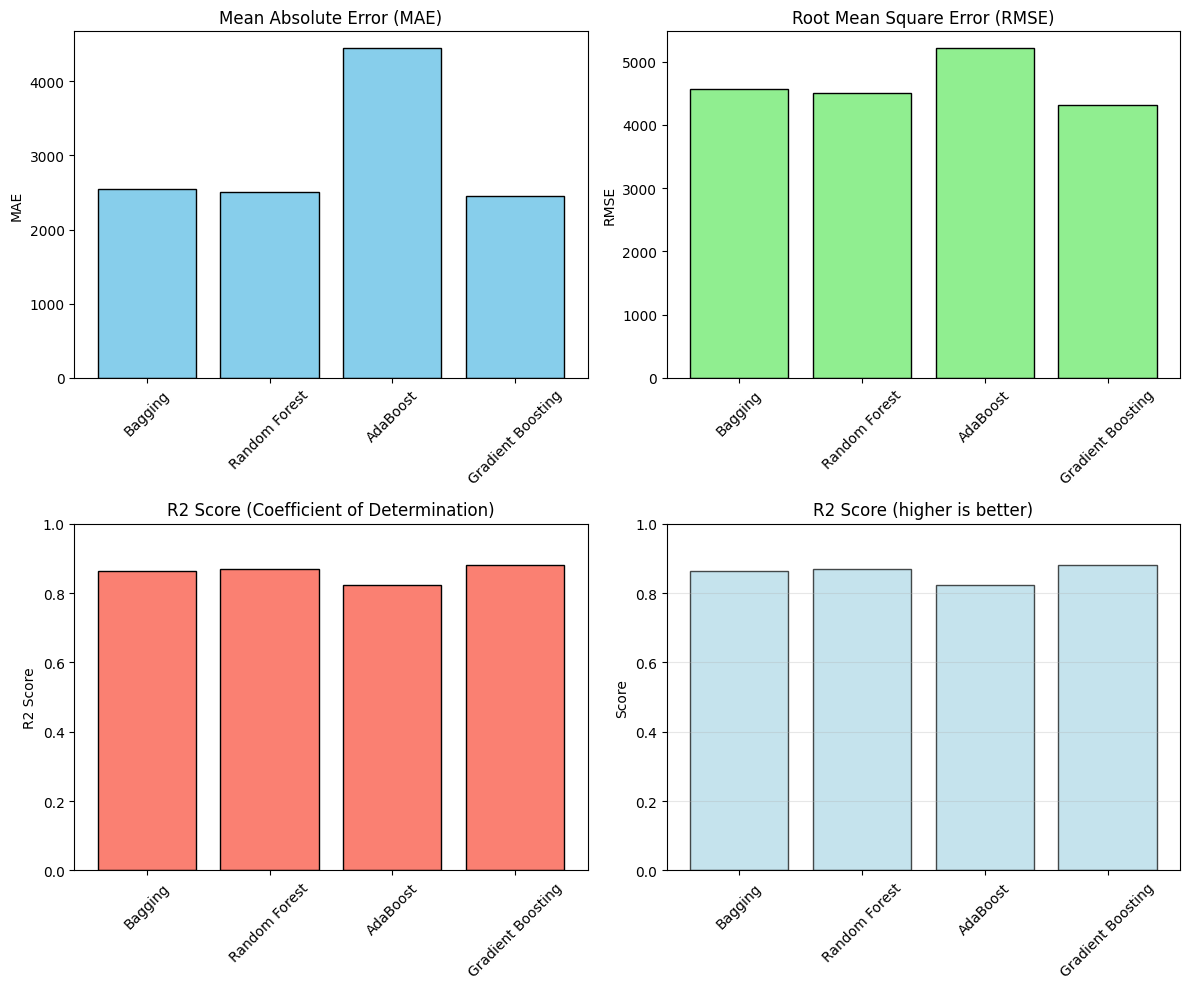


🏆 Лучшая модель по R2 Score: Gradient Boosting
R2 Score: 0.8804


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = []

# Bagging
results.append({
    'Model': 'Bagging',
    'MAE': mean_absolute_error(y_test, y_pred_bag),
    'MSE': mean_squared_error(y_test, y_pred_bag),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_bag)),
    'R2': r2_score(y_test, y_pred_bag)
})

# Random Forest
results.append({
    'Model': 'Random Forest',
    'MAE': mean_absolute_error(y_test, y_pred_RF),
    'MSE': mean_squared_error(y_test, y_pred_RF),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_RF)),
    'R2': r2_score(y_test, y_pred_RF)
})

# AdaBoost
results.append({
    'Model': 'AdaBoost',
    'MAE': mean_absolute_error(y_test, y_pred_Ada),
    'MSE': mean_squared_error(y_test, y_pred_Ada),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_Ada)),
    'R2': r2_score(y_test, y_pred_Ada)
})

# Gradient Boosting
results.append({
    'Model': 'Gradient Boosting',
    'MAE': mean_absolute_error(y_test, y_pred_grad_b),
    'MSE': mean_squared_error(y_test, y_pred_grad_b),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_grad_b)),
    'R2': r2_score(y_test, y_pred_grad_b)
})

results_df = pd.DataFrame(results)
print(results_df.round(4))

# Визуализация сравнения моделей
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# График MAE
axes[0, 0].bar(results_df['Model'], results_df['MAE'], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Mean Absolute Error (MAE)', fontsize=12)
axes[0, 0].set_ylabel('MAE')
axes[0, 0].tick_params(axis='x', rotation=45)

# График RMSE
axes[0, 1].bar(results_df['Model'], results_df['RMSE'], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Root Mean Square Error (RMSE)', fontsize=12)
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].tick_params(axis='x', rotation=45)

# График R2 Score
axes[1, 0].bar(results_df['Model'], results_df['R2'], color='salmon', edgecolor='black')
axes[1, 0].set_title('R2 Score (Coefficient of Determination)', fontsize=12)
axes[1, 0].set_ylabel('R2 Score')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=45)

# График сравнения всех метрик (нормализованных)
for i, metric in enumerate(['MAE', 'RMSE']):
    results_df[f'{metric}_norm'] = (results_df[metric] - results_df[metric].min()) / (results_df[metric].max() - results_df[metric].min())

axes[1, 1].bar(results_df['Model'], results_df['R2'], color='lightblue', edgecolor='black', alpha=0.7, label='R2 Score')
axes[1, 1].set_title('R2 Score (higher is better)', fontsize=12)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Определение лучшей модели по R2
best_model = results_df.loc[results_df['R2'].idxmax(), 'Model']
print(f"\n🏆 Лучшая модель по R2 Score: {best_model}")
print(f"R2 Score: {results_df['R2'].max():.4f}")